In [1]:
!pip install mlflow

In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import torch
import mlflow
import mlflow.pytorch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader,WeightedRandomSampler
from torchvision import transforms,models
from sklearn.metrics import accuracy_score,confusion_matrix,roc_auc_score,recall_score,precision_score,f1_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
APTOS_ROOT = "/content/drive/MyDrive/Diabetic_retinopathy/data/APTOS"

TRAIN_IMG_DIR = f"{APTOS_ROOT}/train_images"
VAL_IMG_DIR   = f"{APTOS_ROOT}/val_images"

TRAIN_CSV = f"{APTOS_ROOT}/train_1.csv"
VAL_CSV   = f"{APTOS_ROOT}/valid.csv"

In [4]:
NUM_CLASSES = 5
IMG_SIZE = 224
BATCH_SIZE = 32
VAL_BATCH_SIZE = 64
EPOCHS = 5
LR = 1e-4
WEIGHT_DECAY = 1e-4
SEED = 42


In [5]:
MODEL_NAME = "resnet50"   # options: "resnet50", "resnet18"
LOSS_TYPE = "focal" # options: "ce", "weighted_ce", "focal"
USE_SAMPLER = False       # True/False
FOCAL_GAMMA = 2.0

In [6]:
EXPERIMENT_NAME = "APTOS_Imbalance_Experiments"

In [7]:
def seed_everything(seed: int = 42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


In [8]:
train_data = pd.read_csv(TRAIN_CSV)
val_data   = pd.read_csv(VAL_CSV)

train_data.columns = train_data.columns.str.strip()
val_data.columns   = val_data.columns.str.strip()

In [9]:
assert "id_code" in train_data.columns and "diagnosis" in train_data.columns, "CSV must have id_code, diagnosis"
assert "id_code" in val_data.columns and "diagnosis" in val_data.columns, "CSV must have id_code, diagnosis"

print("Train rows:", len(train_data), "Val rows:", len(val_data))
print("Train class counts:\n", train_data["diagnosis"].value_counts().sort_index())

Train rows: 2930 Val rows: 366
Train class counts:
 diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64


In [10]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


In [11]:
class APTOSDataset(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _resolve_path(self, img_id: str):
        img_id = str(img_id)

        # if csv has extension already
        if img_id.lower().endswith((".png", ".jpg", ".jpeg")):
            p = os.path.join(self.img_dir, img_id)
            if os.path.exists(p):
                return p

        for ext in [".png", ".jpg", ".jpeg"]:
            p = os.path.join(self.img_dir, img_id + ext)
            if os.path.exists(p):
                return p

        return None

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row["id_code"]
        label = int(row["diagnosis"])

        img_path = self._resolve_path(img_id)
        if img_path is None:
            raise FileNotFoundError(
                f"Missing image for id_code='{img_id}' in '{self.img_dir}'. "
                f"Checked png/jpg/jpeg."
            )

        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        return img, label

In [12]:
train_ds = APTOSDataset(train_data, TRAIN_IMG_DIR, train_tfms)
val_ds   = APTOSDataset(val_data, VAL_IMG_DIR, val_tfms)

In [13]:
def build_train_loader(use_sampler: bool):
    if not use_sampler:
        return DataLoader(
            train_ds,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=2,
            pin_memory=torch.cuda.is_available(),
        )

    labels = train_df["diagnosis"].values
    class_count = np.bincount(labels, minlength=NUM_CLASSES)
    class_weights = 1.0 / np.maximum(class_count, 1)
    sample_weights = class_weights[labels]

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )

    return DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )

train_loader = build_train_loader(USE_SAMPLER)
val_loader = DataLoader(
    val_ds,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

In [14]:
def build_model(name: str):
    if name == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
        return m
    if name == "resnet18":
        m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
        return m
    raise ValueError("Unknown MODEL_NAME")

model = build_model(MODEL_NAME).to(device)

In [15]:
counts = train_data["diagnosis"].value_counts().sort_index().reindex(range(NUM_CLASSES), fill_value=0)
weights = counts.sum() / (NUM_CLASSES * np.maximum(counts.values, 1))
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

In [16]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

In [17]:
if LOSS_TYPE == "ce":
    criterion = nn.CrossEntropyLoss()
elif LOSS_TYPE == "weighted_ce":
    criterion = nn.CrossEntropyLoss(weight=class_weights)
elif LOSS_TYPE == "focal":
    criterion = FocalLoss(alpha=class_weights, gamma=FOCAL_GAMMA)
else:
    raise ValueError("LOSS_TYPE must be one of: ce, weighted_ce, focal")

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

In [18]:
def eval_model(model, loader):
    model.eval()
    all_labels, all_probs, all_preds = [], [], []
    total_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

            all_probs.append(probs)
            all_preds.append(preds)
            all_labels.append(y.cpu().numpy())
            total_loss += loss.item() * x.size(0)

    all_probs = np.concatenate(all_probs)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class="ovr")
    except Exception:
        auc = None

    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

    # per-class recall (especially for class 3 & 4)
    recalls = recall_score(all_labels, all_preds, average=None, labels=list(range(NUM_CLASSES)))
    cm = confusion_matrix(all_labels, all_preds)

    return {
        "loss": avg_loss,
        "acc": acc,
        "auc": auc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "recalls": recalls,
        "cm": cm,
        "labels": all_labels,
        "preds": all_preds,
    }

In [19]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)

In [20]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, title="Confusion Matrix"):
    fig = plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    plt.xticks(range(NUM_CLASSES))
    plt.yticks(range(NUM_CLASSES))
    plt.tight_layout()
    return fig

In [21]:
from sklearn.metrics import classification_report

mlflow.set_experiment(EXPERIMENT_NAME)

run_name = f"{MODEL_NAME}_{LOSS_TYPE}_sampler{USE_SAMPLER}_img{IMG_SIZE}_lr{LR}"
with mlflow.start_run(run_name=run_name):

    # log params
    mlflow.log_param("model_name", MODEL_NAME)
    mlflow.log_param("img_size", IMG_SIZE)
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("epochs", EPOCHS)
    mlflow.log_param("lr", LR)
    mlflow.log_param("weight_decay", WEIGHT_DECAY)
    mlflow.log_param("loss_type", LOSS_TYPE)
    mlflow.log_param("use_sampler", USE_SAMPLER)
    mlflow.log_param("focal_gamma", FOCAL_GAMMA if LOSS_TYPE == "focal" else None)
    mlflow.log_param("seed", SEED)
    mlflow.log_param("device", device)

    # log class weights for reproducibility
    for c in range(NUM_CLASSES):
        mlflow.log_param(f"class_weight_{c}", float(class_weights[c].detach().cpu()))

    best_val_auc = -1
    best_ckpt_path = "best_model.pt"

    for epoch in range(1, EPOCHS + 1):
        tr_loss = train_one_epoch(model, train_loader)
        val_out = eval_model(model, val_loader)

        print(f"\nEpoch {epoch}/{EPOCHS}")
        print(f"Train loss: {tr_loss:.4f}")
        print(f"Val loss:   {val_out['loss']:.4f}")
        print(f"Val acc:    {val_out['acc']:.4f}")
        print(f"Val auc:    {val_out['auc']}")
        print(f"Val macroF1:{val_out['macro_f1']:.4f}")
        print("Val recalls:", val_out["recalls"])
        print("Val CM:\n", val_out["cm"])

        # log metrics per epoch
        mlflow.log_metric("train_loss", tr_loss, step=epoch)
        mlflow.log_metric("val_loss", val_out["loss"], step=epoch)
        mlflow.log_metric("val_acc", val_out["acc"], step=epoch)
        if val_out["auc"] is not None:
            mlflow.log_metric("val_auc", float(val_out["auc"]), step=epoch)
        mlflow.log_metric("val_macro_f1", val_out["macro_f1"], step=epoch)
        mlflow.log_metric("val_weighted_f1", val_out["weighted_f1"], step=epoch)

        # log per-class recall
        for c in range(NUM_CLASSES):
            mlflow.log_metric(f"val_recall_class{c}", float(val_out["recalls"][c]), step=epoch)

        # save best by AUC (or fallback acc if auc None)
        current_score = float(val_out["auc"]) if val_out["auc"] is not None else float(val_out["acc"])
        if current_score > best_val_auc:
            best_val_auc = current_score
            torch.save(model.state_dict(), best_ckpt_path)

    # Final evaluation + artifacts from best checkpoint
    model.load_state_dict(torch.load(best_ckpt_path, map_location=device))
    final_out = eval_model(model, val_loader)

    # Log final metrics
    mlflow.log_metric("best_val_score", best_val_auc)
    mlflow.log_metric("final_val_acc", final_out["acc"])
    if final_out["auc"] is not None:
        mlflow.log_metric("final_val_auc", float(final_out["auc"]))
    mlflow.log_metric("final_val_macro_f1", final_out["macro_f1"])
    mlflow.log_metric("final_val_weighted_f1", final_out["weighted_f1"])

    # Save & log confusion matrix image
    cm_fig = plot_confusion_matrix(final_out["cm"], title=f"CM_{run_name}")
    cm_path = "confusion_matrix.png"
    cm_fig.savefig(cm_path, dpi=200, bbox_inches="tight")
    plt.close(cm_fig)
    mlflow.log_artifact(cm_path)

    # Save & log classification report
    report = classification_report(final_out["labels"], final_out["preds"], digits=4)
    report_path = "classification_report.txt"
    with open(report_path, "w") as f:
        f.write(report)
    mlflow.log_artifact(report_path)

    # Log model as MLflow artifact + raw checkpoint
    mlflow.pytorch.log_model(model, artifact_path="model")
    mlflow.log_artifact(best_ckpt_path)

print("Done. Check MLflow runs (mlruns folder or MLflow UI).")


Epoch 1/5
Train loss: 0.8985
Val loss:   0.7835
Val acc:    0.6557
Val auc:    0.8671794806486771
Val macroF1:0.5249
Val recalls: [0.87209302 0.8        0.29807692 0.36363636 0.67857143]
Val CM:
 [[150  20   0   0   2]
 [  0  32   3   1   4]
 [  3  17  31  13  40]
 [  0   1   1   8  12]
 [  0   3   2   4  19]]

Epoch 2/5
Train loss: 0.5562
Val loss:   0.7593
Val acc:    0.6639
Val auc:    0.8558537322114368
Val macroF1:0.5262
Val recalls: [0.89534884 0.85       0.27884615 0.45454545 0.57142857]
Val CM:
 [[154  16   0   1   1]
 [  0  34   1   2   3]
 [  2  34  29  19  20]
 [  0   3   0  10   9]
 [  0   2   2   8  16]]

Epoch 3/5
Train loss: 0.4252
Val loss:   0.7278
Val acc:    0.7022
Val auc:    0.8991985711734453
Val macroF1:0.5549
Val recalls: [0.88372093 0.775      0.48076923 0.22727273 0.67857143]
Val CM:
 [[152  19   0   0   1]
 [  0  31   5   0   4]
 [  1  18  50   8  27]
 [  0   2   5   5  10]
 [  0   2   4   3  19]]

Epoch 4/5
Train loss: 0.3190
Val loss:   0.7356
Val acc:    

2026/03/11 17:36:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 17:36:10 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/11 17:36:11 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/11 17:36:30 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cpu) contains a local version label (+cpu). M

Done. Check MLflow runs (mlruns folder or MLflow UI).


In [22]:
from google.colab import files
files.download("best_model.pt")
model = build_model(MODEL_NAME)
model.load_state_dict(torch.load("best_model.pt", map_location="cpu"))
model.to(device) # Add this line to move the model to the GPU

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [33]:
import h5py

# Save PyTorch weights as .h5
def save_weights_as_h5(model, filepath):
    with h5py.File(filepath, 'w') as f:
        for name, param in model.state_dict().items():
            f.create_dataset(name, data=param.cpu().numpy())
    print(f"Saved weights to {filepath}")

# Load .h5 weights back into PyTorch model
def load_weights_from_h5(model, filepath):
    state_dict = {}
    with h5py.File(filepath, 'r') as f:
        for key in f.keys():
            state_dict[key] = torch.tensor(np.array(f[key]))
    model.load_state_dict(state_dict)
    print(f"Loaded weights from {filepath}")
    return model

# Usage:
save_weights_as_h5(model, "best_model.h5")
# model = load_weights_from_h5(model, "best_model.h5")

Saved weights to best_model.h5


In [34]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import os

# ---- Grad-CAM helper ----
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        def fwd_hook(module, inp, out):
            self.activations = out.detach()

        def bwd_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.fwd_handle = target_layer.register_forward_hook(fwd_hook)
        self.bwd_handle = target_layer.register_backward_hook(bwd_hook)

    def __call__(self, x, class_idx=None):
        """
        x: input tensor (1, C, H, W)
        class_idx: target class index; if None, uses predicted class
        """
        self.model.zero_grad()
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        score = logits[:, class_idx]
        score.backward(retain_graph=True)

        # activations: (B, C, H, W), gradients: (B, C, H, W)
        grads = self.gradients           # (B, C, H, W)
        acts = self.activations          # (B, C, H, W)

        weights = grads.mean(dim=(2, 3), keepdim=True)  # (B, C, 1, 1)
        cam = (weights * acts).sum(dim=1, keepdim=True) # (B, 1, H, W)
        cam = F.relu(cam)

        # normalize to [0,1]
        cam = cam.squeeze().cpu().numpy()
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)
        return cam, class_idx

    def close(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

In [35]:
# choose target conv layer for ResNet50 (last conv layer of layer4)
target_layer = model.layer4[-1].conv3  # for resnet50
# for resnet18, use: target_layer = model.layer4[-1].conv2

grad_cam = GradCAM(model, target_layer)

def load_single_image(img_path):
    img = Image.open(img_path).convert("RGB")
    img_t = val_tfms(img)          # use same normalization as val set
    return img, img_t.unsqueeze(0).to(device)  # (1, C, H, W)

def show_grad_cam(img_path, true_label=None, target_class=None):
    orig_img, x = load_single_image(img_path)

    cam, used_class = grad_cam(x, class_idx=target_class)
    pred_probs = torch.softmax(model(x), dim=1).detach().cpu().numpy()[0]
    pred_class = int(np.argmax(pred_probs))

    # resize CAM to original size
    cam_resized = cv2.resize(cam, orig_img.size)  # (W, H)

    # overlay heatmap on original image
    heatmap = (cam_resized * 255).astype(np.uint8)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    img_np = np.array(orig_img)[:, :, ::-1]  # RGB -> BGR for cv2
    overlay = cv2.addWeighted(img_np, 0.5, heatmap, 0.5, 0)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(orig_img)
    plt.axis("off")
    plt.title("Original")

    plt.subplot(1, 3, 2)
    plt.imshow(cam_resized, cmap="jet")
    plt.axis("off")
    plt.title("Grad-CAM (class {})".format(used_class))

    plt.subplot(1, 3, 3)
    plt.imshow(overlay[:, :, ::-1])  # back to RGB
    plt.axis("off")
    title = "Pred: {} (p={:.2f})".format(pred_class, pred_probs[pred_class])
    if true_label is not None:
        title += f" | True: {true_label}"
    plt.title(title)

    plt.tight_layout()
    plt.show()

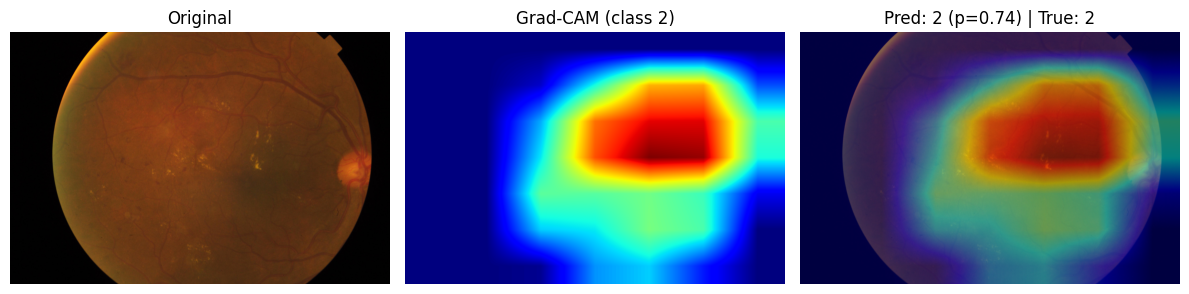

In [36]:
# pick one sample from validation set, e.g., index 0
row = val_data.iloc[0]
img_id = str(row["id_code"])
true_label = int(row["diagnosis"])

# try common extensions
for ext in [".png", ".jpg", ".jpeg"]:
    candidate = os.path.join(VAL_IMG_DIR, img_id + ext)
    if os.path.exists(candidate):
        img_path = candidate
        break

show_grad_cam(img_path, true_label=true_label)

In [37]:
def saliency_map(model, img_tensor, target_class=None):
    """
    img_tensor: (1, C, H, W) normalized
    """
    model.eval()
    img_tensor = img_tensor.clone().detach().requires_grad_(True)
    logits = model(img_tensor)
    if target_class is None:
        target_class = logits.argmax(dim=1).item()
    score = logits[:, target_class]
    score.backward()

    grads = img_tensor.grad.data.abs().max(dim=1)[0]  # (1, H, W) -> take max over channels
    sal = grads.squeeze().cpu().numpy()
    sal -= sal.min()
    sal /= (sal.max() + 1e-8)
    return sal

def show_saliency(img_path):
    orig_img, x = load_single_image(img_path)
    sal = saliency_map(model, x)
    sal_resized = cv2.resize(sal, orig_img.size)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(orig_img)
    plt.axis("off")
    plt.title("Original")

    plt.subplot(1, 2, 2)
    plt.imshow(sal_resized, cmap="hot")
    plt.axis("off")
    plt.title("Saliency")
    plt.tight_layout()
    plt.show()

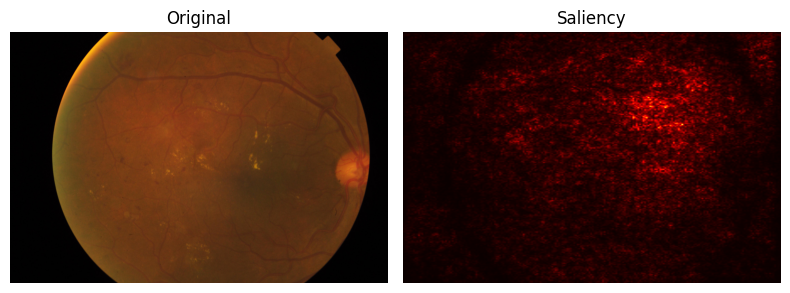

In [38]:
show_saliency(candidate)

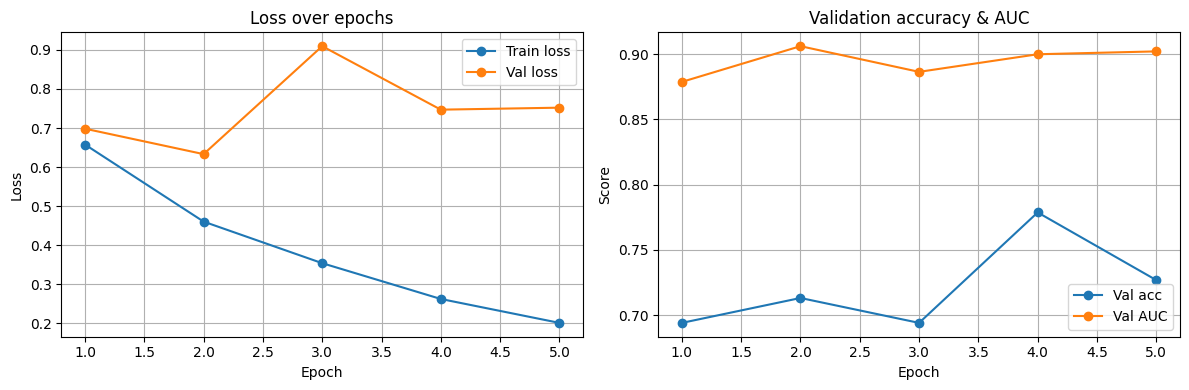

In [39]:
import matplotlib.pyplot as plt

# manually enter from your training log, or store during training
train_losses = [0.6577, 0.4605, 0.3541, 0.2625, 0.2013]
val_losses   = [0.6983, 0.6332, 0.9095, 0.7470, 0.7521]
val_accs     = [0.6940, 0.7131, 0.6940, 0.7787, 0.7268]
val_aucs     = [0.8788, 0.9062, 0.8865, 0.9000, 0.9022]

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs, train_losses, '-o', label='Train loss')
plt.plot(epochs, val_losses,   '-o', label='Val loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Loss over epochs')
plt.grid(True); plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, val_accs, '-o', label='Val acc')
plt.plot(epochs, val_aucs, '-o', label='Val AUC')
plt.xlabel('Epoch'); plt.ylabel('Score')
plt.title('Validation accuracy & AUC')
plt.grid(True); plt.legend()

plt.tight_layout()
plt.show()

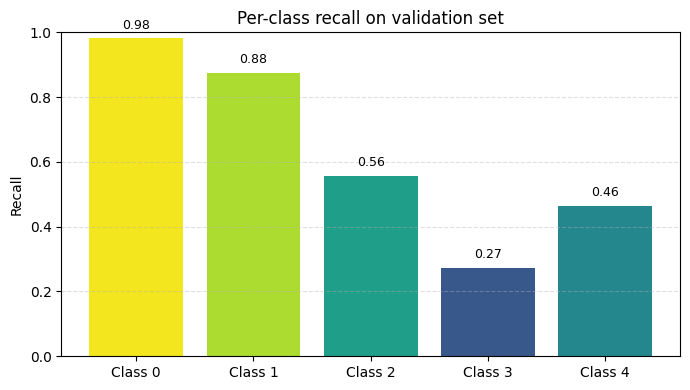

In [40]:
import numpy as np
import matplotlib.pyplot as plt

class_names = [f"Class {i}" for i in range(NUM_CLASSES)]
recalls = final_out["recalls"]  # numpy array shape (5,)

plt.figure(figsize=(7,4))
bars = plt.bar(class_names, recalls, color=plt.cm.viridis(recalls))

plt.ylim(0, 1.0)
plt.ylabel("Recall")
plt.title("Per-class recall on validation set")
plt.grid(axis='y', linestyle='--', alpha=0.4)

for bar, r in zip(bars, recalls):
    plt.text(bar.get_x() + bar.get_width()/2, r + 0.02,
             f"{r:.2f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

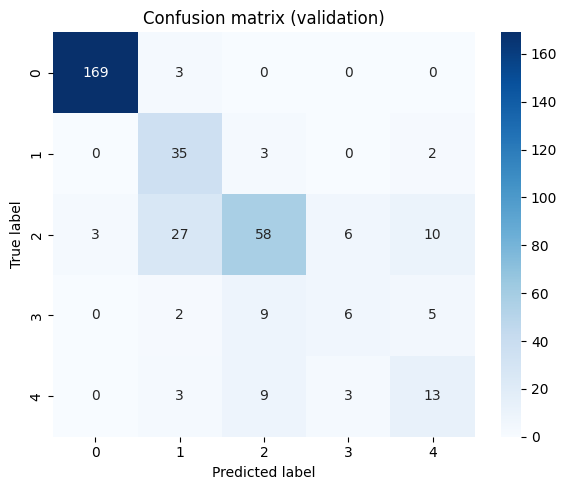

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = final_out["cm"]  # shape (5,5)
class_names = [f"{i}" for i in range(NUM_CLASSES)]

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix (validation)")
plt.tight_layout()
plt.show()

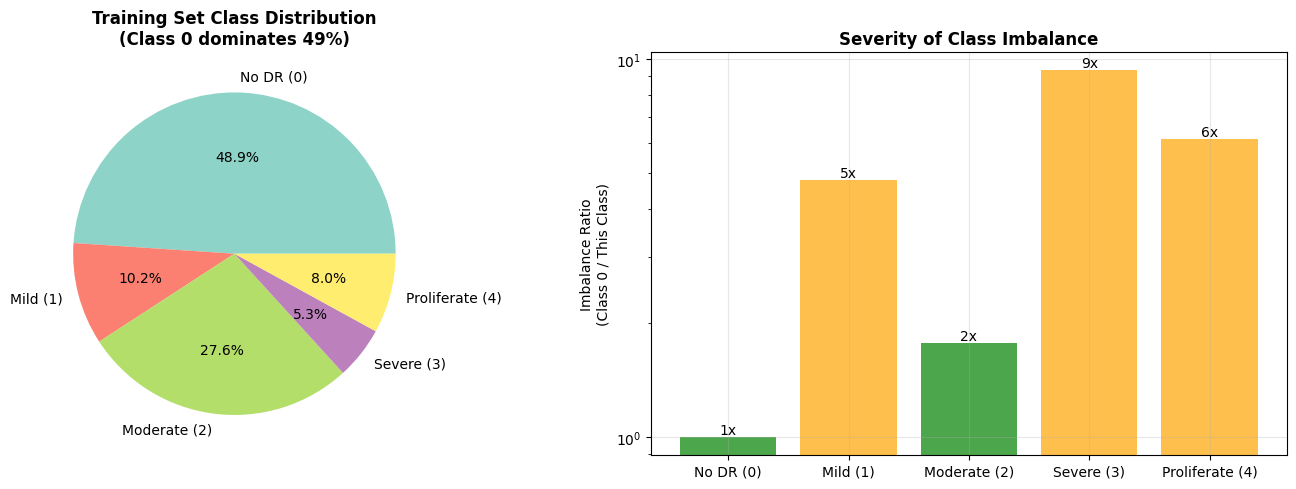

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Your train class counts from notebook
train_counts = [1434, 300, 808, 154, 234]  # class 0,1,2,3,4
class_names = ['No DR (0)', 'Mild (1)', 'Moderate (2)', 'Severe (3)', 'Proliferate (4)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart with percentages
wedges, texts, autotexts = ax1.pie(train_counts, labels=class_names, autopct='%1.1f%%',
                                   colors=plt.cm.Set3(np.linspace(0, 1, 5)))
ax1.set_title('Training Set Class Distribution\n(Class 0 dominates 49%)', fontsize=12, fontweight='bold')

# Imbalance ratio bars
ratios = [train_counts[0]/c if c > 0 else float('inf') for c in train_counts]
colors = ['green' if r < 2 else 'orange' if r < 10 else 'red' for r in ratios]
bars = ax2.bar(class_names, ratios, color=colors, alpha=0.7)
ax2.set_ylabel('Imbalance Ratio\n(Class 0 / This Class)')
ax2.set_title('Severity of Class Imbalance', fontweight='bold')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

# Annotate bars
for bar, r in zip(bars, ratios):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{r:.0f}x', ha='center', va='bottom')

plt.tight_layout()
plt.show()

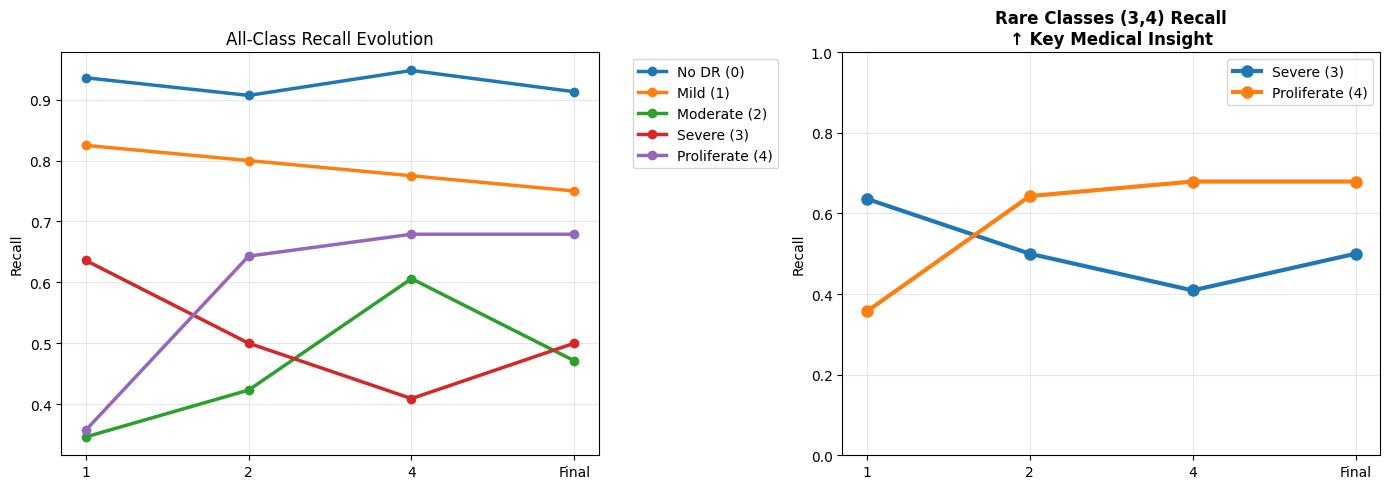

In [43]:
# From your final_out or epoch recalls (example data from your log)
recalls_epoch1 = [0.936, 0.825, 0.346, 0.636, 0.357]
recalls_epoch2 = [0.907, 0.800, 0.423, 0.500, 0.643]
recalls_epoch4 = [0.948, 0.775, 0.606, 0.409, 0.679]  # your best epoch
recalls_final = [0.913, 0.750, 0.471, 0.500, 0.679]

epochs_recalls = np.array([recalls_epoch1, recalls_epoch2, recalls_epoch4, recalls_final])
rare_class_idx = [3, 4]  # Severe/Proliferate (your key classes)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# All class recall curves
x_epochs = [1, 2, 4, 'Final']
for i, label in enumerate(class_names):
    ax1.plot(x_epochs, epochs_recalls[:, i], 'o-', label=label, linewidth=2.5)

ax1.set_ylabel('Recall'); ax1.set_title('All-Class Recall Evolution')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# ZOOM: Rare classes only
for i in rare_class_idx:
    ax2.plot(x_epochs, epochs_recalls[:, i], 'o-', linewidth=3,
             label=class_names[i], markersize=8)
ax2.set_ylabel('Recall'); ax2.set_title('Rare Classes (3,4) Recall\n↑ Key Medical Insight', fontweight='bold')
ax2.set_ylim(0, 1); ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

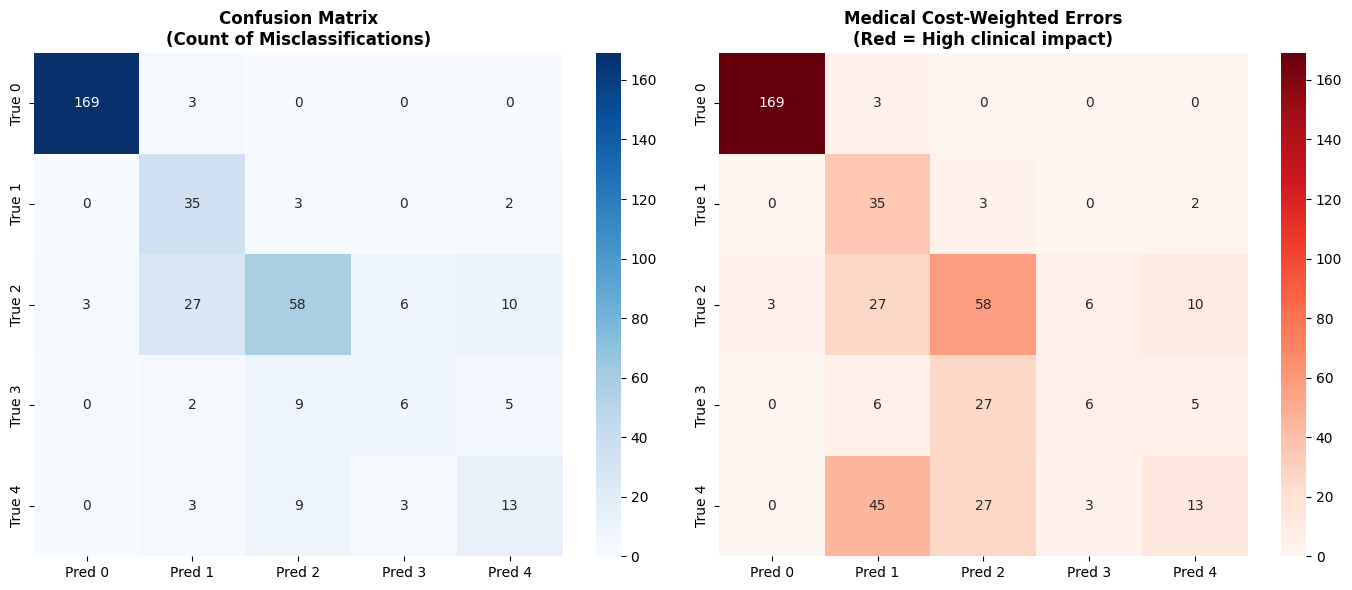

💡 Key Insight: Model misses Severe/Proliferate cases (rows 3,4 → cols 0-2)
   → Weighted cost shows true clinical risk of these errors


In [44]:
import seaborn as sns
cm = final_out["cm"]  # your final confusion matrix

# Medical cost matrix: False Negatives for severe classes hurt more
cost_matrix = np.ones_like(cm)
cost_matrix[3:, 0:3] *= 3  # FN for severe classes (rows 3,4 to cols 0,1,2) = 3x cost
cost_matrix[4, 0:2] *= 5   # FN for Proliferate (row 4 to cols 0,1) = 5x cost

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[f'Pred {i}' for i in range(5)],
            yticklabels=[f'True {i}' for i in range(5)])
axes[0].set_title('Confusion Matrix\n(Count of Misclassifications)', fontweight='bold')

# Cost-weighted confusion matrix
sns.heatmap(cm * cost_matrix, annot=True, fmt='.0f', cmap='Reds', ax=axes[1],
            xticklabels=[f'Pred {i}' for i in range(5)],
            yticklabels=[f'True {i}' for i in range(5)])
axes[1].set_title('Medical Cost-Weighted Errors\n(Red = High clinical impact)', fontweight='bold')

plt.tight_layout()
plt.show()

print("💡 Key Insight: Model misses Severe/Proliferate cases (rows 3,4 → cols 0-2)")
print("   → Weighted cost shows true clinical risk of these errors")